<a href="https://colab.research.google.com/github/MIL-Project2/DR-DT/blob/main/Occupancy_Prediction_Ver1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# 1. Set your user info (Git is already installed!)
!git config --global user.email "jwas0006@student.monash.edu"
!git config --global user.name "MIL-Project2"

# 2. Clone your repo (if you haven't already)
!git clone https://github.com/MIL-Project2/DR-DT.git
%cd DR-DT

# 3. Make your changes or add new files...

# 4. Push back to GitHub
!git add .
!git commit -m "Updated from Colab"

# 5. Push using your Personal Access Token (paste it when prompted for a password)
!git push

Cloning into 'DR-DT'...
remote: Enumerating objects: 88, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 88 (delta 43), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (88/88), 2.63 MiB | 9.18 MiB/s, done.
Resolving deltas: 100% (43/43), done.
/content/DR-DT/DR-DT/DR-DT/DR-DT/DR-DT
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address


In [21]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
#import warnings
#warnings.filterwarnings('ignore')

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

print("All libraries imported successfully.")

All libraries imported successfully.


In [22]:
df = pd.read_csv('Occupancy-Prediction_Generated_Ver_1_2.csv', delimiter=',')

In [23]:
# ── Missing Values, Data Types & Duplicates ──────────────────────────────────
print("=== DATA AUDIT REPORT ===")
column_info = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Missing Values': df.isnull().sum(),
    'Missing (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
display(column_info)
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print(f"\nStatistical Summary:")
display(df.describe().round(2))

=== DATA AUDIT REPORT ===


,Data Type,Non-Null Count,Missing Values,Missing (%)
collecteddate,object,54759,0,0.0
floorspaceid,object,54759,0,0.0
headcount,int64,54759,0,0.0
temperature,float64,0,54759,100.0
humidity,float64,0,54759,100.0
co2,float64,0,54759,100.0



Duplicate Rows: 0

Statistical Summary:


,headcount,temperature,humidity,co2
count,54759.00,0.0,0.0,0.0
mean,2.24,NaN,NaN,NaN
std,2.85,NaN,NaN,NaN
min,0.00,NaN,NaN,NaN
25%,1.00,NaN,NaN,NaN
50%,2.00,NaN,NaN,NaN
75%,3.00,NaN,NaN,NaN
max,21.00,NaN,NaN,NaN


## **Exploratory Data Analysis (EDA)**

This section consolidates and extends the EDA. The analysis is structured around two research questions:

- **Q1:** What is the distribution of the target variable “headcount"?
- **Q2:** Which numerical features are most strongly correlated with “headcount”?

### **The distribution of the target variable “headcount"**

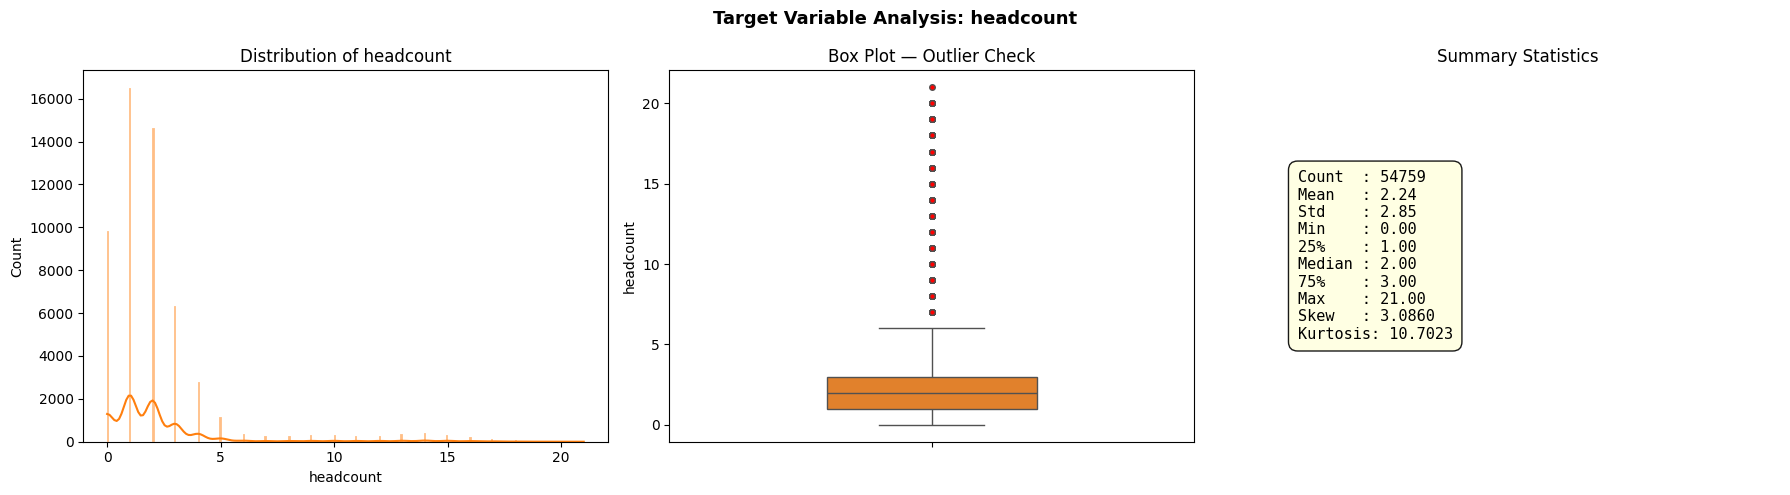

Skewness : 3.0860  (|skew| < 0.5 = approx. normal)
Kurtosis : 10.7023
IQR-based outliers : 3208 (5.9%)


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram + KDE
sns.histplot(df['headcount'], kde=True, ax=axes[0], color='tab:orange', edgecolor='white')
axes[0].set_title('Distribution of headcount')
axes[0].set_xlabel('headcount'); axes[0].set_ylabel('Count')

# Box plot — outlier check
sns.boxplot(y=df['headcount'], ax=axes[1], color='tab:orange', width=0.4,
            flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
axes[1].set_title('Box Plot — Outlier Check')
axes[1].set_ylabel('headcount')

# Summary statistics panel
desc = df['headcount'].describe()
lines = [f"Count  : {desc['count']:.0f}",
         f"Mean   : {desc['mean']:.2f}",
         f"Std    : {desc['std']:.2f}",
         f"Min    : {desc['min']:.2f}",
         f"25%    : {desc['25%']:.2f}",
         f"Median : {desc['50%']:.2f}",
         f"75%    : {desc['75%']:.2f}",
         f"Max    : {desc['max']:.2f}",
         f"Skew   : {df['headcount'].skew():.4f}",
         f"Kurtosis: {df['headcount'].kurtosis():.4f}"]
axes[2].axis('off')
axes[2].text(0.08, 0.5, '\n'.join(lines), transform=axes[2].transAxes,
             fontsize=11, verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='lightyellow', alpha=0.9))
axes[2].set_title('Summary Statistics')

plt.suptitle('Target Variable Analysis: headcount', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

print(f"Skewness : {df['headcount'].skew():.4f}  (|skew| < 0.5 = approx. normal)")
print(f"Kurtosis : {df['headcount'].kurtosis():.4f}")
q1, q3 = df['headcount'].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = df[(df['headcount'] < q1 - 1.5*iqr) | (df['headcount'] > q3 + 1.5*iqr)]
print(f"IQR-based outliers : {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

### **Numerical features are most strongly correlated with “headcount”**

Pearson Correlation with Headcount (sorted by absolute value):
             Correlation
temperature          NaN
humidity             NaN
co2                  NaN


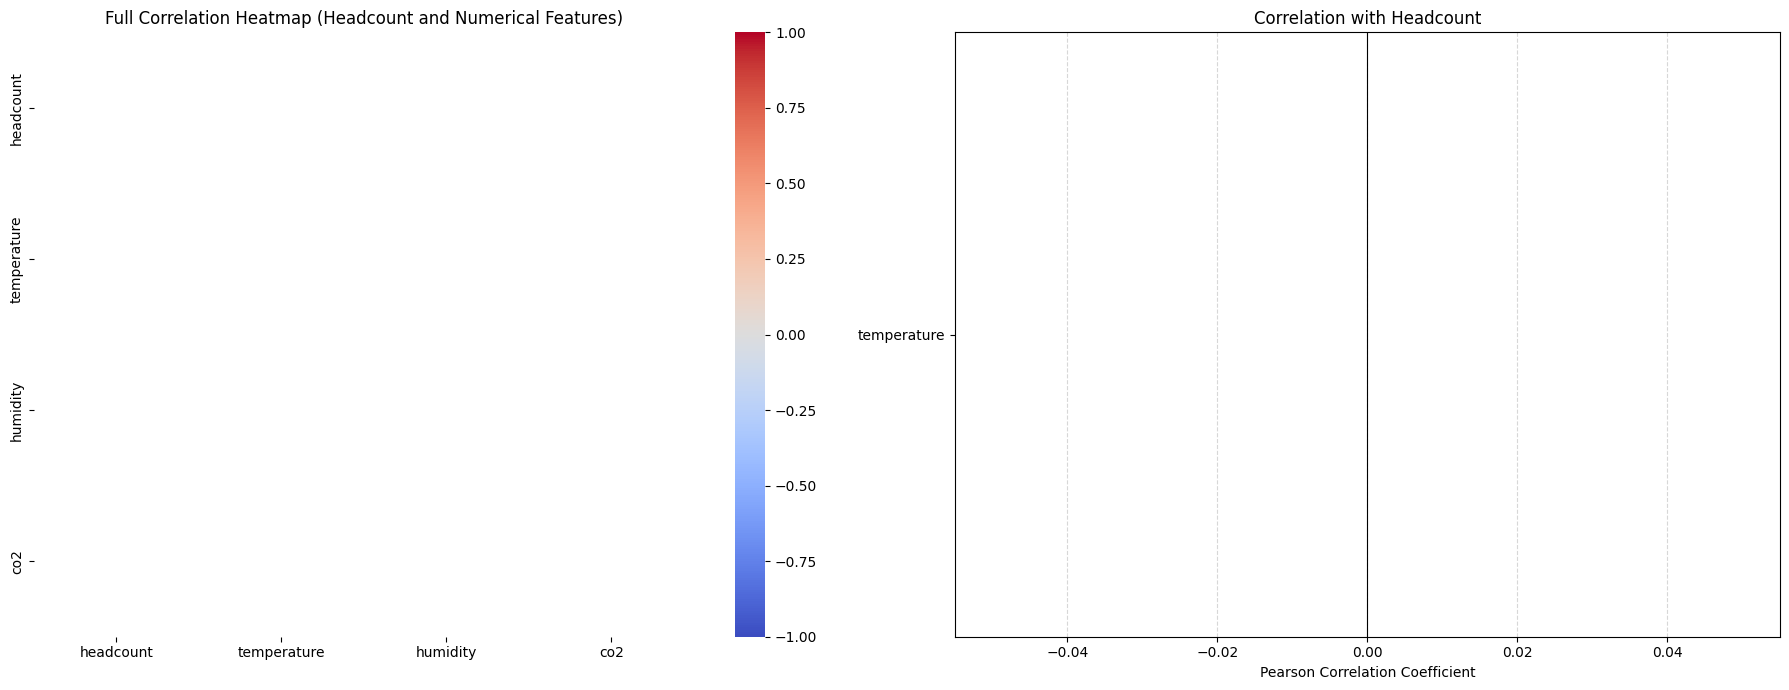

In [25]:
import numpy as np
# Identify numerical features relevant for correlation with 'headcount'
numerical_features = [
    'temperature', 'humidity', 'co2'
]

# Ensure 'headcount' is included for correlation calculation
cols_for_corr = ['headcount'] + numerical_features

# Calculate correlation matrix
corr_matrix_headcount = df[cols_for_corr].corr()

# Correlation with headcount (sorted by absolute value)
headcount_corr = corr_matrix_headcount['headcount'].drop('headcount').sort_values(key=abs, ascending=False)
print("Pearson Correlation with Headcount (sorted by absolute value):")
print(headcount_corr.to_frame('Correlation').round(4))

# Visualize correlations with heatmap and bar chart
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full correlation heatmap (only for the selected numerical features and headcount)
mask = np.triu(np.ones_like(corr_matrix_headcount, dtype=bool))
sns.heatmap(corr_matrix_headcount, annot=True, cmap='coolwarm', fmt='.2f',
            mask=mask, ax=axes[0], linewidths=0.5, vmin=-1, vmax=1)
axes[0].set_title('Full Correlation Heatmap (Headcount and Numerical Features)', fontsize=12)

# Bar chart of correlations with headcount
colors_headcount = ['#d73027' if v > 0 else '#4575b4' for v in headcount_corr.values]
axes[1].barh(headcount_corr.index, headcount_corr.values, color=colors_headcount)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with Headcount', fontsize=12)
axes[1].set_xlabel('Pearson Correlation Coefficient')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)
for i, v in enumerate(headcount_corr.values):
    axes[1].text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## **Data Cleaning & Preprocessing**

This section outlines the data cleaning and preprocessing steps necessary to prepare the `df` DataFrame for machine learning tasks. Building upon the initial data audit and EDA, this stage focuses on:

1.  **Timestamp Conversion**: Converting the `collecteddate` column to datetime objects and extracting useful time-based features (e.g., `hour_of_day`, `day_of_week`) that might influence occupancy.
2.  **Feature Engineering**: Adding `occupancy_lag_5min`,	`occupancy_lag_10min`,	`occupancy_lag_15min`,	`occupancy_rolling_15min`,	`co2_rolling_15min`,	`temperature_rolling_15min`.
3.  **Outlier Strategy**: Deciding on an approach to handle the outliers identified in the `headcount` target variable and other numerical features.
4.  **Feature Scaling**: Applying appropriate scaling techniques to numerical features to ensure they are on a comparable scale for various machine learning algorithms.

### **DateTime Conversion**

In [28]:
df['collecteddate'] = pd.to_datetime(df['collecteddate'], format='%Y-%m-%d %H:%M:%S%z', errors='coerce', utc=True)
df['day_of_week'] = df['collecteddate'].dt.dayofweek
df['hour_of_day'] = df['collecteddate'].dt.hour
df['minute_of_day'] = df['collecteddate'].dt.minute
display(df.head())

,collecteddate,floorspaceid,headcount,temperature,humidity,co2,day_of_week,hour_of_day,minute_of_day
0,2024-07-07 19:27:44+00:00,9f902aab-58fe-4b1c-ab24-241310df1550,1,NaN,NaN,NaN,6,19,27
1,2024-07-07 19:28:42+00:00,9f902aab-58fe-4b1c-ab24-241310df1550,0,NaN,NaN,NaN,6,19,28
2,2024-07-07 19:29:04+00:00,9f902aab-58fe-4b1c-ab24-241310df1550,0,NaN,NaN,NaN,6,19,29
3,2024-07-07 19:40:44+00:00,9f902aab-58fe-4b1c-ab24-241310df1550,1,NaN,NaN,NaN,6,19,40
4,2024-07-07 19:41:22+00:00,9f902aab-58fe-4b1c-ab24-241310df1550,0,NaN,NaN,NaN,6,19,41
